# 00 — Introduction to `geopyv_dev`

**Digital Image Correlation (DIC)** measures full-field displacements and strains from
photographs of a deforming surface — no strain gauges, no contact.  `geopyv_dev` is a
high-performance Python package (Rust core, PyO3 bindings) that implements the complete
DIC pipeline.

## Tutorial map

| Notebook | Topic |
|----------|-------|
| **00 — you are here** | What is DIC? Package overview |
| **01** | `Image`, `Mask`, `CircleRegion`, `PathRegion` |
| **02** | `Subset` — single-point correlation |
| **03** | `Mesh` — full-field single image pair |
| **04** | `Sequence` — multi-image time series |
| **05** | `Particle` & `Field` — strain-path tracking |

> **Setup:** activate your virtual environment and ensure `geopyv_dev` is installed
> (`pip install geopyv_dev` or `maturin develop` from the repo root).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "animation.embed_limit": 50,
})


## What is DIC?

The core idea is simple:

1. **Photograph** the surface before deformation (the *reference* image).
2. **Deform** the specimen — mechanically, thermally, or any other way.
3. **Photograph** again (the *target* image).
4. **Correlate** small square or circular patches (*subsets*) between the two images
   to find where each part of the surface moved.

The animation below shows this process. Each red box is a subset — a small region whose
intensity pattern is matched to the target image to recover the local displacement.


NameError: name 'os' is not defined

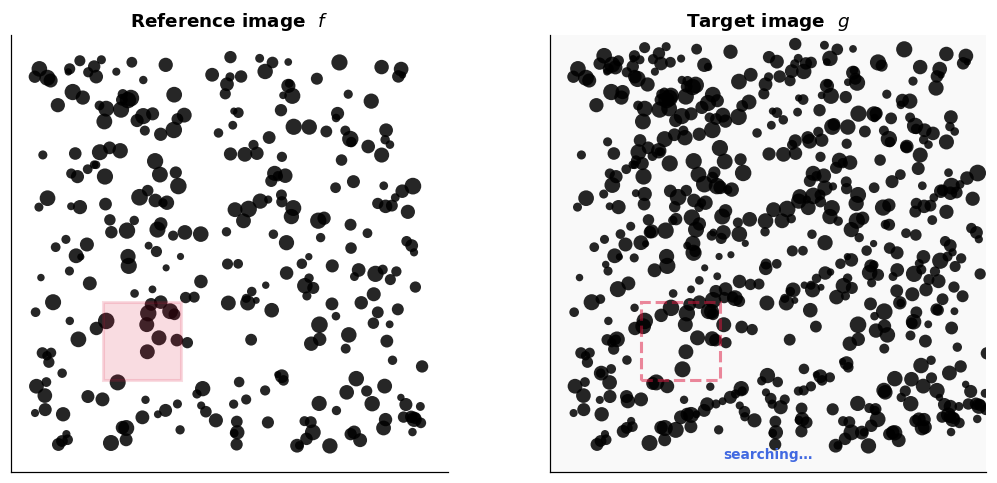

In [2]:
# --- Animated DIC concept diagram ---
rng = np.random.RandomState(42)
n = 300
xs, ys = rng.uniform(10, 190, n), rng.uniform(10, 190, n)
sz = rng.uniform(20, 120, n)

DX, DY = 12, 6           # true displacement applied to target
SUBSETS = [              # subset centres to animate through
    (60, 60), (130, 60), (60, 130), (130, 130), (95, 95),
]

fig, (ax_r, ax_t) = plt.subplots(1, 2, figsize=(10, 4.5), facecolor="white")
for ax, title in [(ax_r, "Reference image  $f$"),
                   (ax_t, "Target image  $g$")]:
    ax.scatter(xs, ys, s=sz, c="k", alpha=0.85, linewidths=0)
    if ax is ax_t:
        ax.scatter(xs + DX, ys + DY, s=sz, c="k", alpha=0.85, linewidths=0)
        ax.set_facecolor("#f9f9f9")
    ax.set_xlim(0, 200); ax.set_ylim(0, 200)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

W = 36   # subset width/height
ref_box = patches.Rectangle((0, 0), W, W, lw=2, ec="crimson", fc="crimson", alpha=0.15)
tar_box = patches.Rectangle((0, 0), W, W, lw=2, ec="seagreen", fc="none", ls="--")
ax_r.add_patch(ref_box)
ax_t.add_patch(tar_box)
arrow = ax_t.annotate("", xy=(0, 0), xytext=(0, 0),
                       arrowprops=dict(arrowstyle="->", color="royalblue", lw=2))
status = ax_t.text(100, 5, "", ha="center", va="bottom", fontsize=9,
                   color="royalblue", fontweight="bold")

N_FRAMES = len(SUBSETS) * 20   # 20 frames per subset (search + lock)

def update(frame):
    si = frame // 20
    phase = frame % 20
    cx, cy = SUBSETS[si]
    ref_box.set_xy((cx - W/2, cy - W/2))

    if phase < 10:           # "searching" phase — box slides in from reference position
        frac = phase / 9
        tx = cx - W/2 + frac * DX * 0.8
        ty = cy - W/2 + frac * DY * 0.8
        tar_box.set(xy=(tx, ty), ec="crimson", alpha=0.5)
        status.set_text("searching…")
    else:                    # "locked on" phase
        tar_box.set(xy=(cx - W/2 + DX, cy - W/2 + DY), ec="seagreen", alpha=1.0)
        arrow.xy = (cx + DX, cy + DY)
        arrow.xyann = (cx, cy)
        status.set_text(f"Δu={DX}, Δv={DY} px")

    return ref_box, tar_box, arrow, status

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=80, blit=True)
plt.tight_layout()
os.makedirs("../docs/assets", exist_ok=True)
anim.save("../docs/assets/nb0_dic_concept.gif", writer="pillow", fps=12)
HTML(anim.to_jshtml())


## Why does DIC need a speckle pattern?

A plain, uniform surface has no features to track — every patch looks the same.
DIC requires a **random, high-contrast texture** so each subset has a unique intensity
fingerprint that can be matched reliably.

The most common approach: spray a thin coat of white paint, then speckle with black
aerosol from a distance.  Key rules of thumb:

- Speckle diameter ≈ **3–7 pixels** (too small → aliasing; too large → low contrast gradient)
- Coverage ≈ **40–60 %** of the surface
- No repeating pattern (lattices, gratings, etc. cause false matches)

`geopyv_dev` includes a `Speckle` class to generate synthetic speckle images for testing.


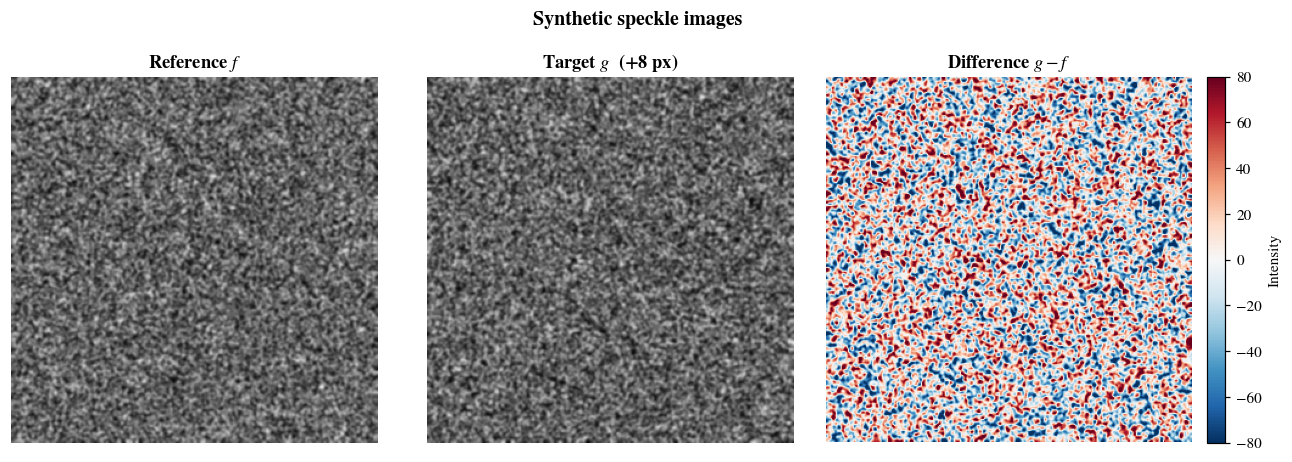

In [3]:
# Generate a quick synthetic speckle pair to illustrate the pattern
import os
import geopyv_dev as gp

os.makedirs("data/single", exist_ok=True)
_sp = gp.Speckle(
    image_cfg={"image_dir": "data/single", "name": "intro", "image_size": (301, 301)},
    speckle_cfg={"speckle_size": 3.5, "speckle_number": 500},
    progression="deformation",
    deformation_cfg={"comp": [8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
    noise_cfg=(0.0, 2.0),
    scale_cfg={"scale": "lin", "n": 2},
)
_sp.solve(seed=7)

_f = gp.Image(filepath="data/single/intro_0.jpg")
_g = gp.Image(filepath="data/single/intro_1.jpg")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, img, lbl in [(axes[0], _f.image_gs, "Reference $f$"),
                      (axes[1], _g.image_gs, "Target $g$  (+8 px)")]:
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(lbl, fontsize=12, fontweight="bold")
    ax.axis("off")

diff = _g.image_gs - _f.image_gs
im = axes[2].imshow(diff, cmap="RdBu_r", vmin=-80, vmax=80)
axes[2].set_title("Difference $g - f$", fontsize=12, fontweight="bold")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Intensity")
plt.suptitle("Synthetic speckle images", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("../docs/assets/nb0_speckle_pair.png", dpi=120, bbox_inches="tight")
plt.show()


## Package structure

`geopyv_dev` objects form a clear hierarchy — start at the bottom and work up:

```
Image  ──►  Mask (local / global)
               │
               ▼
            Subset  ◄──── single point, single pair
               │
               ▼
             Mesh   ◄──── full field, single pair
               │
               ▼
           Sequence ◄──── full field, image time series
               │
          ┌────┴────┐
          ▼          ▼
       Particle    Field ◄──── strain-path tracking
```

The diagram below maps these objects onto the two main workflows.


In [ ]:
# Package hierarchy and workflow overview
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5); ax.axis("off")

COLORS = {
    "data":     "#dbeafe",   # blue-tinted
    "core":     "#dcfce7",   # green-tinted
    "analysis": "#fef9c3",   # yellow-tinted
}

def box(ax, x, y, w, h, label, sublabel="", color="#f0f0f0"):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                   fc=color, ec="steelblue", lw=1.4)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.12 if sublabel else 0), label,
            ha="center", va="center", fontsize=10, fontweight="bold")
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.22, sublabel,
                ha="center", va="center", fontsize=8, color="#555")

def arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.5))

# Data layer
box(ax, 0.2, 3.8, 2.2, 1.2, "Image", "greyscale + B-spline", COLORS["data"])
box(ax, 2.7, 3.8, 2.2, 1.2, "Mask", "local or global", COLORS["data"])

# Core layer
box(ax, 0.2, 2.2, 2.2, 1.2, "Subset", "single point", COLORS["core"])
box(ax, 2.7, 2.2, 2.2, 1.2, "Mesh", "full field", COLORS["core"])
box(ax, 5.2, 2.2, 2.2, 1.2, "Sequence", "time series", COLORS["core"])

# Analysis layer
box(ax, 2.7, 0.5, 2.2, 1.2, "Particle", "1 tracking pt", COLORS["analysis"])
box(ax, 5.2, 0.5, 2.2, 1.2, "Field", "N tracking pts", COLORS["analysis"])

# Arrows
arrow(ax, 1.3, 3.8, 1.3, 3.4)
arrow(ax, 3.8, 3.8, 3.8, 3.4)
arrow(ax, 2.2, 2.8, 2.7, 2.8)        # Image → Mask (shared)
arrow(ax, 3.8, 2.2, 3.8, 1.7)        # Mesh → Particle
arrow(ax, 6.3, 2.2, 6.3, 1.7)        # Sequence → Field
arrow(ax, 4.9, 2.8, 5.2, 2.8)        # Mesh → Sequence

# Workflow labels
ax.text(3.8, 0.2, "Workflow A: single pair", ha="center", va="bottom",
        fontsize=9, color="steelblue", style="italic")
ax.text(6.3, 0.2, "Workflow B: time series", ha="center", va="bottom",
        fontsize=9, color="steelblue", style="italic")

plt.title("geopyv_dev object hierarchy", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
fig.savefig("../docs/assets/nb0_hierarchy.png", dpi=120, bbox_inches="tight")
plt.show()


## What can DIC measure?

Once you have a solved `Mesh` or `Sequence`, you have access to:

| Quantity | Where | Notes |
|----------|-------|-------|
| Displacement **u**, **v** | `mesh.displacements` | Per-node, pixels |
| Warp vector **p** | `mesh.p` | 6 (order-1) or 12 (order-2) params per node |
| Correlation score C_ZNCC | `mesh.c_zncc` | 1.0 = perfect; < 0.7 = suspect |
| Strain components | `particle.strains` | Via `Particle` or `Field` |
| Volumetric strain | `particle.vol_strains` | Via `Particle` or `Field` |

Next up: **Notebook 01** — loading images and building masks.
